In [1]:
import pickle
import numpy as np
import matplotlib.pyplot as plt

from neural_decoder.neural_decoder_trainer import loadModel

In [2]:
# model_name = "MODEL-NAME"
# display_model_name = "DISPLAY TEXT"
model_name = "conv-lstm-reduced-features"
display_model_name = "TDS Conv-LSTM with Reduced Spike Band Powers and Threshold Crossings"

training_stats = None

with open(f"../models/{model_name}/trainingStats", "rb") as f:
    training_stats = pickle.load(f)

In [8]:
model = loadModel(f"../models/{model_name}")
total_params = sum(p.numel() for p in model.parameters())
print(f"Total parameters for {display_model_name}: {total_params}")

Total parameters for TDS Conv-LSTM with Reduced Spike Band Powers and Threshold Crossings: 5560745


In [4]:
print(f"Final Validation CTC loss for {display_model_name} is {training_stats['testLoss'][-1]}")
print(f"Final Validation PER for {display_model_name} is {training_stats['testCER'][-1]}")

print(f"Best Validation CTC loss for {display_model_name} is {np.min(training_stats['testLoss'])} at iteration {np.argmin(training_stats['testLoss']) * 100}")
print(f"Best Validation PER for {display_model_name} is {np.min(training_stats['testCER'])} at iteration {np.argmin(training_stats['testCER']) * 100}")

Final Validation CTC loss for TDS Conv-LSTM with Reduced Spike Band Powers and Threshold Crossings is 0.8161611557006836
Final Validation PER for TDS Conv-LSTM with Reduced Spike Band Powers and Threshold Crossings is 0.20663612727497832
Best Validation CTC loss for TDS Conv-LSTM with Reduced Spike Band Powers and Threshold Crossings is 0.7964794295174735 at iteration 14100
Best Validation PER for TDS Conv-LSTM with Reduced Spike Band Powers and Threshold Crossings is 0.20548058272460898 at iteration 14800


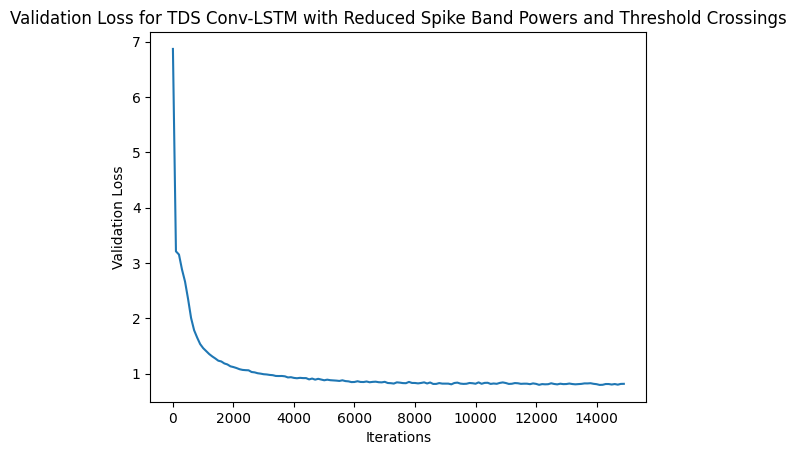

In [6]:
plt.plot(np.arange(0, training_stats['testLoss'].shape[0] * 100, 100), training_stats['testLoss'])
plt.xlabel('Iterations')
plt.ylabel('Validation Loss')
plt.title(f'Validation Loss for {display_model_name}')

plt.savefig(f"../models/{model_name}/val_loss.png")
plt.show()

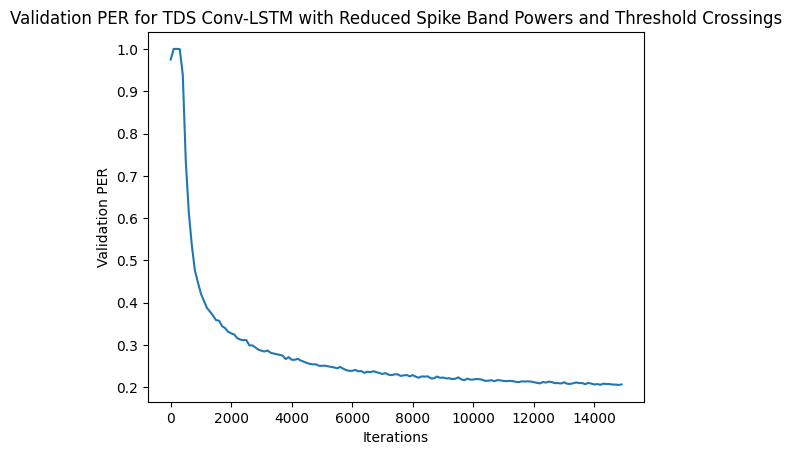

In [7]:
plt.plot(np.arange(0, training_stats['testCER'].shape[0] * 100, 100), training_stats['testCER'])
plt.xlabel('Iterations')
plt.ylabel('Validation PER')
plt.title(f'Validation PER for {display_model_name}')

plt.savefig(f"../models/{model_name}/val_cer.png")
plt.show()